# Koduppgift 4

### uppgift 11

In [1]:
from sklearn.metrics import classification_report 
y_true = [0, 1, 2, 2, 2] 
y_pred = [0, 0, 2, 2, 1] 
target_names = ['class 0', 'class 1', 'class 2'] 
print(classification_report(y_true, y_pred, target_names=target_names))

              precision    recall  f1-score   support

     class 0       0.50      1.00      0.67         1
     class 1       0.00      0.00      0.00         1
     class 2       1.00      0.67      0.80         3

    accuracy                           0.60         5
   macro avg       0.50      0.56      0.49         5
weighted avg       0.70      0.60      0.61         5



classification_report vissar hur bra en model har presterat

om vi kollar på våra värden så ser vi att index 1 och 4 är fel medans övriga är rätt.

vi kollar sen på hur dom olika modellerna har presterat med klassificering

precision: kollar hur ofta modellen har rätt när den påstår att den hittat rätt

recall: kollar hur många gånger modellen hitta posiviva värden

f1: är en blanding av precision och recall och är därför ett genomsnitt av båda

svm: har bara kollat hur många gången något blivit in klassificerat

### Uppgift 12

In [2]:
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

In [3]:
X,y = load_wine(return_X_y=True)

In [4]:
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X,y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

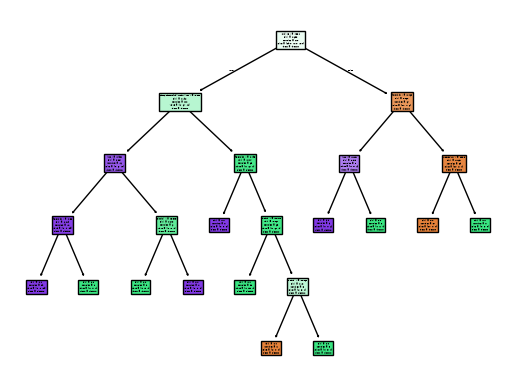

In [5]:
plt.Figure(figsize=(12,8))
plot_tree(dtc, filled=True, feature_names=load_wine().feature_names, class_names=load_wine().target_names)
plt.show()

### Uppgift 13

In [6]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [7]:
df = pd.read_excel('./dataset/hr_employee_data.xlsx') #ladda in data
df.info() #kolla datan

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  str    
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   left                   14999 non-null  int64  
 8   promotion_last_5years  14999 non-null  int64  
 9   Department             14999 non-null  str    
 10  salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(3)
memory usage: 1.3 MB


Jag kommer att börja med att köra på dom sakerna som jag tog upp i kap 3 uppgiften och kommer därför kolla vilka som lämnar baserat på arbetsplatsolyckor, och hur tillfredsställda dom är på jobbet. jag känner att antal projekt per department antagligen inte kommer at ge oss så mycket egentligen. 

In [8]:
X = df.drop(columns=['Department', 'salary', 'left', 'Emp_Id']) #tar bort strängar, left (våran y) och emp_id då det inte är relevant
y = df['left']

In [9]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   promotion_last_5years  14999 non-null  int64  
dtypes: float64(2), int64(5)
memory usage: 820.4 KB


In [10]:
y.info()

<class 'pandas.Series'>
RangeIndex: 14999 entries, 0 to 14998
Series name: left
Non-Null Count  Dtype
--------------  -----
14999 non-null  int64
dtypes: int64(1)
memory usage: 117.3 KB


Splita upp X och Y i train, val, test

In [11]:
X_full, X_test, y_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_full, y_full, test_size=0.3, random_state=35)


Använder Scaler för att normalisera våran data

In [12]:

scaler = StandardScaler()

X_scaler_full = scaler.fit_transform(X_full)
X_scaler_train = scaler.fit_transform(X_train)
X_scaler_val = scaler.transform(X_val)
X_scaler_test = scaler.transform(X_test)

Tränar våran model

In [13]:
lr = LogisticRegression()
lr.fit(X_scaler_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

utvärderar våran model

In [14]:
lr_pred = lr.predict(X_scaler_val)
val_ac = accuracy_score(y_val, lr_pred)

print(f"Validation Accuracy: {val_ac:.4f}")

Validation Accuracy: 0.7633


In [15]:
lr.fit(X_scaler_full, y_full)

lr_pred_2 = lr.predict(X_scaler_test)

print(classification_report(y_test, lr_pred_2))

              precision    recall  f1-score   support

           0       0.79      0.92      0.85      2294
           1       0.46      0.23      0.30       706

    accuracy                           0.76      3000
   macro avg       0.63      0.57      0.58      3000
weighted avg       0.72      0.76      0.72      3000



<Figure size 600x600 with 0 Axes>

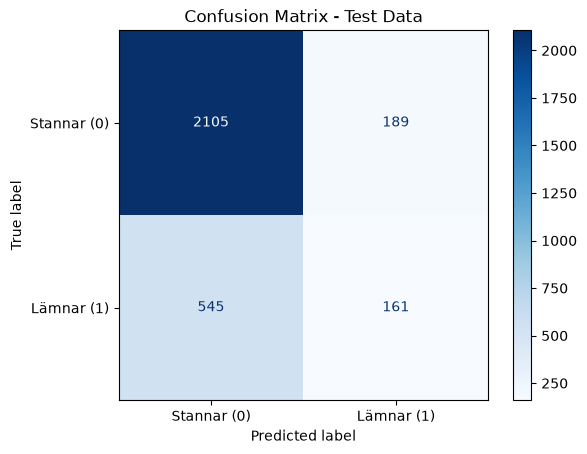

In [16]:
plt.figure(figsize=(6, 6))
cm = confusion_matrix(y_test, lr_pred_2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stannar (0)', 'Lämnar (1)'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix - Test Data")
plt.show()

### Uppgift 14

In [17]:
from sklearn.datasets import load_iris

In [18]:
iris = load_iris()

print(iris.DESCR)
print(iris.target_names)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [19]:
X,y = load_iris(return_X_y=True, as_frame=True)

X = X[['sepal length (cm)', 'sepal width (cm)']]

In [20]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.3, random_state=36)

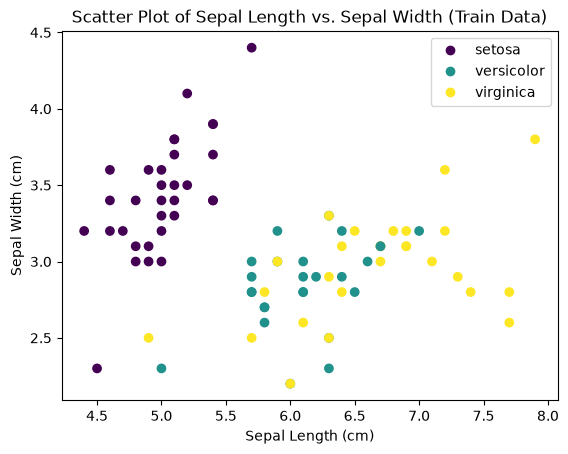

In [21]:
classes = ['setosa', 'versicolor', 'virginica'] 

scatter = plt.scatter(X_train['sepal length (cm)'], X_train['sepal width (cm)'], c=y_train)
plt.xlabel('Sepal Length (cm)') 
plt.ylabel('Sepal Width (cm)') 
plt.title('Scatter Plot of Sepal Length vs. Sepal Width (Train Data)')
plt.legend(handles=scatter.legend_elements()[0], labels=classes)

Här kommer då hur jag hade tänkt att träna och kolla en modell på den här datan.

Jag hade tänkte att använda mig av en random forest. varför? för att låta den tränas i flera seg för att se vad dom hade varit mest optimalt.

jag hade även tänk att använda en baggingclassifier för att se om det hade ger bättre resultat..

varför jag kör dom har 2 mot varandra är för att dom är ganska lika och kan kanske därför bli intressant att gemföra.

#### Random Forest

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)
rf_hyperparams={
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_hyperparams,
    cv=5,
    scoring='accuracy',
    n_jobs=1
)

rf_grid.fit(X_train, y_train)

print("bästa params:", rf_grid.best_params_)
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)
print(classification_report(y_test, y_pred_rf))


bästa params: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         8
           1       0.69      0.75      0.72        12
           2       0.86      0.60      0.71        10

    accuracy                           0.77        30
   macro avg       0.78      0.78      0.77        30
weighted avg       0.78      0.77      0.76        30



#### Bagging

In [25]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Skapa och optimera Bagging Classifier
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42)
bagging_params = {
    'n_estimators': [50, 100, 200],
    'estimator__max_depth': [None, 10, 20]
}

bagging_grid = GridSearchCV(estimator=bagging, param_grid=bagging_params, cv=5, scoring='accuracy', n_jobs=-1)
bagging_grid.fit(X_train, y_train)

print("Bästa parametrarna:", bagging_grid.best_params_)
bagging_best = bagging_grid.best_estimator_
y_pred_bagging = bagging_best.predict(X_test)
print(classification_report(y_test, y_pred_bagging))

Bästa parametrarna: {'estimator__max_depth': None, 'n_estimators': 50}
              precision    recall  f1-score   support

           0       0.88      0.88      0.88         8
           1       0.54      0.58      0.56        12
           2       0.56      0.50      0.53        10

    accuracy                           0.63        30
   macro avg       0.66      0.65      0.65        30
weighted avg       0.63      0.63      0.63        30



#### Slutsats

När vi nu gemför dom här 2 ser ser vi att scoret på random forest är mycket bättre. det är nästan 0.1 bättre på alla score.

vilket gör att vi har en ganska så klar vinnare

Det jag blir lite nyfiken på är om vi hade kunnat ta en model som hade kunnat komma över 0.8 

efter att ha kollat lite i boken så hamnade jag på sida 196 och bestämde mig för att köra en SVM och en logistic bara för att ha gemföra alla. (sen var dagens lektion inställd så jag har inte mycket annat för mig.)

#### Logistic

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42, max_iter=2000))
])

lr_hyperparams = {
    'lr__C': [0.01, 0.1, 1, 10],
    'lr__solver':['lbfgs', 'saga']
}

model_lr_poly = GridSearchCV(
    estimator=pipeline,
    param_grid=lr_hyperparams,
    cv=5,
    scoring='accuracy',
    n_jobs=1
)

model_lr_poly.fit(X_train,y_train)

print("Bästa parametrarna:", model_lr_poly.best_params_)
lr_best = model_lr_poly.best_estimator_
y_pred_lr = lr_best.predict(X_test)
print(classification_report(y_test, y_pred_lr))


Bästa parametrarna: {'lr__C': 0.1, 'lr__solver': 'lbfgs'}
              precision    recall  f1-score   support

           0       0.89      1.00      0.94         8
           1       0.83      0.83      0.83        12
           2       0.89      0.80      0.84        10

    accuracy                           0.87        30
   macro avg       0.87      0.88      0.87        30
weighted avg       0.87      0.87      0.87        30



Jag ska vara helt ärlig så trodde jag inte att Logistic skulle vara så här pass mycket bättre. den är nästan 0.1 bättre än random forest. nu är ju bara frågan om jag ska twika med params på RF för att se om dom kan bli bättre

ska göra SVM först för att ha en total genförelse

#### SVM

In [31]:
from sklearn.svm import SVC

pipeline_svc = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

svc_hyperparams = {
    'svc__C': [0.01, 0.1, 1, 10],
    'svc__kernel':['rbf', 'poly', 'linear']
}

model_svc = GridSearchCV(
    estimator=pipeline_svc,
    param_grid=svc_hyperparams,
    cv=5,
    scoring='accuracy',
    n_jobs=1
)

model_svc.fit(X_train,y_train)

print("Bästa parametrarna:", model_svc.best_params_)
svm_best = model_svc.best_estimator_
y_pred_svm = svm_best.predict(X_test)
print(classification_report(y_test, y_pred_svm))

Bästa parametrarna: {'svc__C': 0.1, 'svc__kernel': 'linear'}
              precision    recall  f1-score   support

           0       0.89      1.00      0.94         8
           1       0.62      0.83      0.71        12
           2       0.80      0.40      0.53        10

    accuracy                           0.73        30
   macro avg       0.77      0.74      0.73        30
weighted avg       0.75      0.73      0.71        30



nu är vi har testat alla våra modeller är det dags att köra vidare på logistic som var bäst

### Slut testet med vinnaren

vi tränar våran bästa model på all data

In [32]:
best_model = model_lr_poly

best_model.fit(X_train_val,y_train_val)

y_pred_final = best_model.predict(X_test)
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94         8
           1       0.83      0.83      0.83        12
           2       0.89      0.80      0.84        10

    accuracy                           0.87        30
   macro avg       0.87      0.88      0.87        30
weighted avg       0.87      0.87      0.87        30



resultat är samma som innan

In [33]:
import joblib

joblib.dump(best_model, 'vinnaren')
print('vinnaren är sparad för återandvänding')

vinnaren är sparad för återandvänding


Resultat:

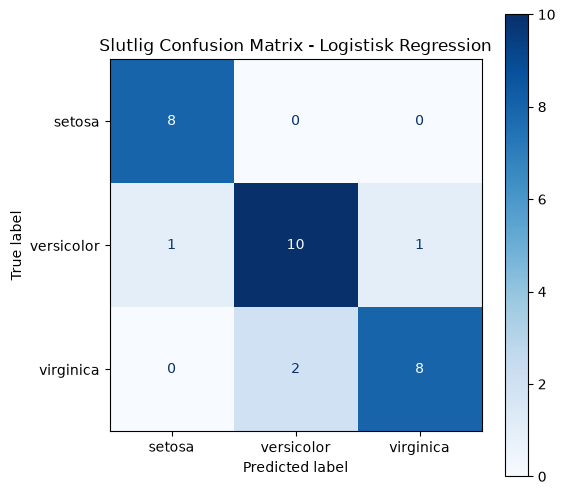

In [35]:
classes = ['setosa', 'versicolor', 'virginica']

plt.figure(figsize=(6, 6))
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.gca())
plt.title("Slutlig Confusion Matrix - Logistisk Regression")
plt.show()


# Koduppgift 15

Jag kände att det började bli mycket i den notebooken så jag la koduppgift 15 i en egen fil [koduppgift 15](Koduppgift-15-kapitel-4.ipynb)